In [ ]:
## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, random
import optuna
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, average_precision_score
)

warnings.filterwarnings("ignore")

SEED   = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [2]:
DATA_PATH = "network_qoe_latest.csv"
OUT_DIR   = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

COLORS = ['#2563eb','#dc2626','#16a34a','#d97706','#7c3aed','#0891b2']

config = {
    "SEQ_LEN" : 64,
    "HIDDEN"  : 256,
    "LATENT"  : 64,
    "LR"      : 1e-4,
    "EPOCHS"  : 100,
    "PATIENCE": 12,
    "BATCH"   : 256,
}

FEATURES = [
    'e2e_delay_ms', 'plr', 'jitter_ms', 'mos_voice', 'throughput_mbps',
    'buffering_ratio', 'call_setup_time_ms', 'streaming_mos',
    'ctrl_plane_rtt_ms', 'rebuffering_freq', 'rebuffering_count',
    'total_stall_seconds', 'cdr_flag', 'effective_bitrate_mbps',
    'dns_latency_ms', 'video_start_time_ms',
]

KEY_FEATS = ['e2e_delay_ms','plr','jitter_ms','mos_voice','throughput_mbps','buffering_ratio']

QOE_FEATS = [
    'e2e_delay_ms', 'plr', 'jitter_ms', 'mos_voice', 'throughput_mbps',
    'buffering_ratio', 'availability', 'dns_latency_ms', 'streaming_mos',
    'effective_bitrate_mbps', 'call_setup_time_ms', 'ctrl_plane_rtt_ms',
]

In [3]:
def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32 + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

set_seeds(SEED)

In [4]:
df = pd.read_csv(DATA_PATH)
df.info()
print(f"Missing values : {df.isna().sum().sum()}")
print(f"Anomaly rate   : {(df['label'] != 'NORMAL').mean()*100:.1f}%")
df.describe().round(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152071 entries, 0 to 152070
Data columns (total 33 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   run_id                  152071 non-null  object 
 1   timestamp               152071 non-null  float64
 2   datetime                152071 non-null  object 
 3   segment                 152071 non-null  object 
 4   switch_id               152071 non-null  int64  
 5   port_no                 152071 non-null  int64  
 6   mos_voice               152071 non-null  float64
 7   e2e_delay_ms            152071 non-null  float64
 8   plr                     152071 non-null  float64
 9   jitter_ms               152071 non-null  float64
 10  cdr_flag                152071 non-null  int64  
 11  call_setup_time_ms      152071 non-null  float64
 12  buffering_ratio         152071 non-null  float64
 13  rebuffering_freq        152071 non-null  float64
 14  rebuffering_count   

,timestamp,switch_id,port_no,mos_voice,e2e_delay_ms,plr,jitter_ms,cdr_flag,call_setup_time_ms,buffering_ratio,...,availability,rx_bytes,tx_bytes,rx_packets,tx_packets,rx_dropped,tx_dropped,dataplane_latency_ms,ctrl_plane_rtt_ms,flow_count
count,1.520710e+05,152071.0,152071.000,152071.000,152071.000,152071.000,152071.000,152071.000,152071.000,152071.000,...,152071.000,1.520710e+05,1.520710e+05,152071.000,152071.000,152071.0,152071.0,108411.000,152071.000,152071.000
mean,1.775782e+09,1.0,2.500,3.463,30.848,0.098,3.687,0.183,866.917,0.934,...,0.872,1.351373e+09,1.169727e+09,2562181.508,2232635.078,0.0,0.0,38.204,12.530,5.196
std,2.796161e+04,0.0,1.118,1.187,43.260,0.213,6.434,0.387,1666.359,0.136,...,0.256,1.634543e+09,9.997537e+08,2321319.870,1541676.362,0.0,0.0,46.802,24.878,2.366
min,1.775733e+09,1.0,1.000,1.000,0.000,0.000,0.000,0.000,200.000,0.000,...,0.000,0.000000e+00,0.000000e+00,0.000,0.000,0.0,0.0,4.788,0.000,0.000
25%,1.775758e+09,1.0,1.000,2.549,9.486,0.000,1.066,0.000,304.200,0.907,...,0.925,9.837881e+07,4.167320e+08,588040.000,1007126.000,0.0,0.0,9.514,9.362,4.000
50%,1.775782e+09,1.0,3.000,4.102,13.052,0.011,2.664,0.000,369.100,0.961,...,0.988,7.480894e+08,8.374774e+08,1882755.000,2020733.000,0.0,0.0,19.596,11.427,6.000
75%,1.775806e+09,1.0,4.000,4.391,23.878,0.074,4.141,0.000,671.400,0.995,...,1.000,2.015891e+09,1.632631e+09,4161908.500,3101667.000,0.0,0.0,35.316,13.687,7.000
max,1.775830e+09,1.0,4.000,4.400,3293.902,1.000,408.245,1.000,10000.000,1.000,...,1.000,6.419977e+09,4.097482e+09,8139921.000,6650767.000,0.0,0.0,279.699,3293.902,48.000


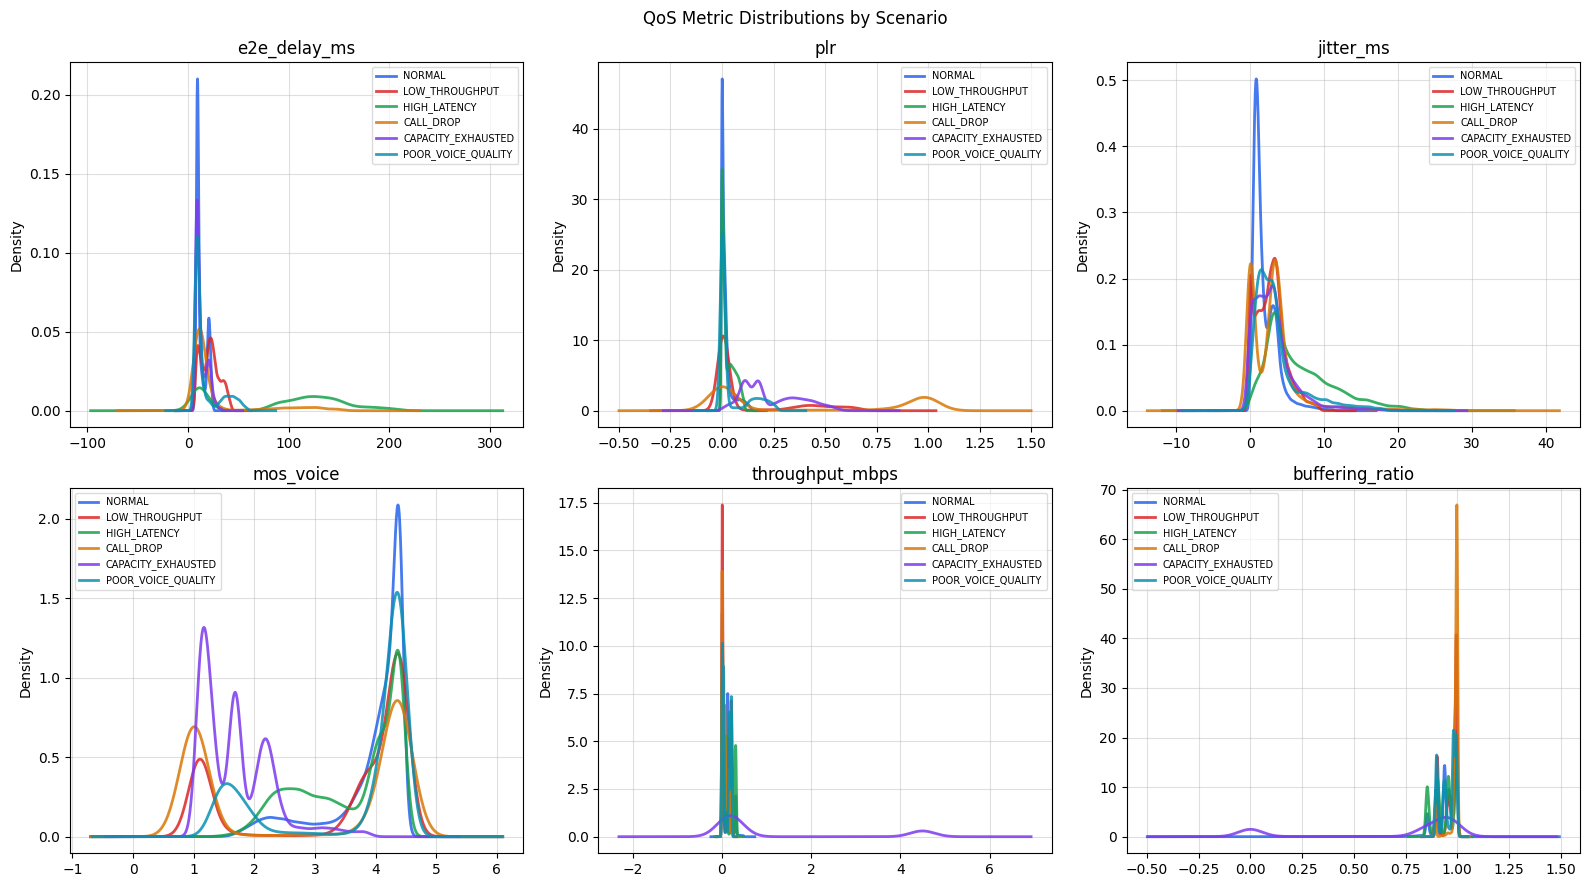

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('QoS Metric Distributions by Scenario')
l2c = dict(zip(df['label'].unique(), COLORS))

for ax, feat in zip(axes.flat, KEY_FEATS):
    for lbl, col in l2c.items():
        s = df[df['label'] == lbl][feat].dropna()
        s = s[s <= s.quantile(0.99)]
        try: s.plot.kde(ax=ax, label=lbl, color=col, lw=2, alpha=0.85)
        except: pass
    ax.set_title(feat); ax.legend(fontsize=7, framealpha=0.7); ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()

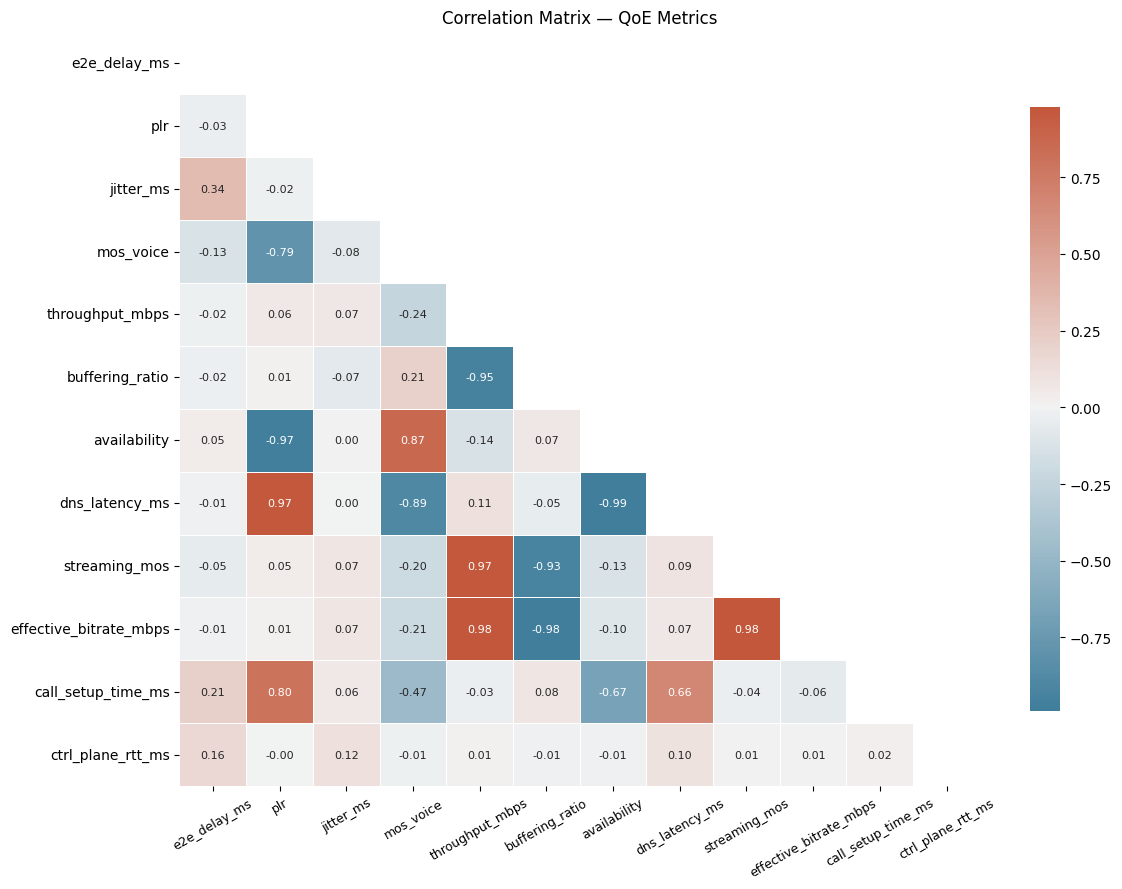

In [6]:
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(df[QOE_FEATS].corr(), dtype=bool))
sns.heatmap(df[QOE_FEATS].corr(), mask=mask,
            cmap=sns.diverging_palette(230, 20, as_cmap=True),
            center=0, annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.5, linecolor='white', ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — QoE Metrics')
for t in ax.get_xticklabels():
    t.set_rotation(30); t.set_fontsize(9)
plt.tight_layout()
plt.show()

In [7]:
def apply_clips(X, features, clip_bounds):
    X = X.copy()
    for i, feat in enumerate(features):
        lo, hi = clip_bounds[feat]
        X[:, i] = np.clip(X[:, i], lo, hi)
    return X

def scale_windows(windows, scaler):
    shape = windows.shape
    return scaler.transform(windows.reshape(-1, shape[-1])).reshape(shape)

In [8]:
df_sorted  = df.sort_values('timestamp').reset_index(drop=True)
df_normal  = df_sorted[df_sorted['label'] == 'NORMAL'].reset_index(drop=True)
df_anormal = df_sorted[df_sorted['label'] != 'NORMAL'].reset_index(drop=True)

duration    = df_normal['timestamp'].max() - df_normal['timestamp'].min()
sample_rate = len(df_normal) / duration
window_size = int(round(sample_rate * 60))
print(f"Sample rate: {sample_rate:.3f} samples/sec | Window size: {window_size} rows")

X_normal_raw = df_normal[FEATURES].values
n_windows    = len(X_normal_raw) // window_size
windows      = X_normal_raw[:n_windows * window_size].reshape(n_windows, window_size, len(FEATURES))

rng     = np.random.default_rng(SEED)
windows = windows[rng.permutation(n_windows)]

i_val, i_test      = int(n_windows * 0.70), int(n_windows * 0.85)
train_windows_raw  = windows[:i_val]
val_windows_raw    = windows[i_val:i_test]
test_windows_raw   = windows[i_test:]

print(f"Train windows: {train_windows_raw.shape} | Val: {val_windows_raw.shape} | Test: {test_windows_raw.shape}")

Sample rate: 0.503 samples/sec | Window size: 30 rows
Train windows: (1136, 30, 16) | Val: (244, 30, 16) | Test: (244, 30, 16)


In [9]:
X_train_raw = train_windows_raw.reshape(-1, len(FEATURES))

clip_bounds = {
    feat: (np.percentile(X_train_raw[:, i], 1), np.percentile(X_train_raw[:, i], 99))
    for i, feat in enumerate(FEATURES)
}

scaler = RobustScaler()
scaler.fit(apply_clips(X_train_raw, FEATURES, clip_bounds))

train_windows_sc = scaler.transform(
    apply_clips(X_train_raw, FEATURES, clip_bounds)
).reshape(train_windows_raw.shape)

val_windows_sc  = scale_windows(val_windows_raw,  scaler)
test_windows_sc = scale_windows(test_windows_raw, scaler)

In [10]:
X_anormal_sc    = scaler.transform(df_anormal[FEATURES].values)
n_anom_windows  = len(X_anormal_sc) // window_size
anom_windows_sc = X_anormal_sc[:n_anom_windows * window_size].reshape(
    n_anom_windows, window_size, len(FEATURES)
)
anom_windows_sc  = anom_windows_sc[rng.permutation(n_anom_windows)]

n_anom_w          = len(anom_windows_sc)
val_anom_windows  = anom_windows_sc[:n_anom_w // 2]
test_anom_windows = anom_windows_sc[n_anom_w // 2:]

print(f"Val anom windows : {val_anom_windows.shape}")
print(f"Test anom windows: {test_anom_windows.shape}")

Val anom windows : (1722, 30, 16)
Test anom windows: (1722, 30, 16)


In [ ]:
def youden_threshold(y_true, scores):
    fpr_v, tpr_v, thresholds = roc_curve(y_true, scores)
    return float(thresholds[np.argmax(tpr_v - fpr_v)])

def find_threshold_at_fpr(fpr_arr, tpr_arr, thresholds, target_fpr=0.10):
    idx = np.where(fpr_arr <= target_fpr)[0]
    return float(thresholds[0] if len(idx) == 0 else thresholds[idx[np.argmax(tpr_arr[idx])]])

def evaluate(name, y_true, scores, threshold):
    preds = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return {
        'name': name, 'threshold': round(threshold, 4),
        'Accuracy':  accuracy_score(y_true, preds),
        'Recall':    recall_score(y_true, preds, zero_division=0),
        'Precision': precision_score(y_true, preds, zero_division=0),
        'F1':        f1_score(y_true, preds, zero_division=0),
        'FPR':       fp / (fp + tn) if (fp + tn) > 0 else 0.0,
        'AUC':       roc_auc_score(y_true, scores),
        'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn),
        'scores': scores, 'preds': preds,
    }

def plot_cm(r, ax):
    cm = np.array([[r['TN'], r['FP']], [r['FN'], r['TP']]])
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Normal','Anomaly']); ax.set_yticklabels(['Normal','Anomaly'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black',
                    fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f"{r['name']}\nAcc={r['Accuracy']*100:.1f}%  F1={r['F1']:.3f}  AUC={r['AUC']:.3f}")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

def plot_recon_dist(ax, scores, y_true, threshold, title):
    bins = np.linspace(0, 1, 80)
    ax.hist(scores[y_true==0], bins=bins, color='#2563eb', alpha=0.6, label='Normal', density=True)
    ax.hist(scores[y_true==1], bins=bins, color='#dc2626', alpha=0.6, label='Anomaly', density=True)
    ax.axvline(threshold, color='black', ls='--', lw=2, label=f'Youden={threshold:.3f}')
    ax.set_title(title); ax.set_xlabel('Reconstruction Score')
    ax.set_ylabel('Density'); ax.legend(fontsize=9); ax.grid(alpha=0.4)

In [13]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, hidden_dim * 2)
        self.v    = nn.Linear(hidden_dim * 2, 1, bias=False)

    def forward(self, hidden_states):
        weights = torch.softmax(self.v(torch.tanh(self.attn(hidden_states))).squeeze(2), dim=1)
        return torch.bmm(weights.unsqueeze(1), hidden_states).squeeze(1)


class AttnBiLSTMAutoencoder(nn.Module):
    def __init__(self, n_feat, hidden=256, latent=64, dropout=0.2):
        super().__init__()
        self.encoder   = nn.LSTM(n_feat, hidden, batch_first=True, bidirectional=True)
        self.attention = Attention(hidden)
        self.enc_fc    = nn.Linear(hidden * 2, latent)
        self.enc_h_fc  = nn.Linear(hidden * 2, hidden)
        self.enc_c_fc  = nn.Linear(hidden * 2, hidden)
        self.decoder   = nn.LSTM(latent, hidden, batch_first=True)
        self.dec_fc    = nn.Linear(hidden, n_feat)
        self.drop      = nn.Dropout(dropout)

    def forward(self, x):
        outputs, (h, c) = self.encoder(x)
        h_cat = torch.cat([h[0], h[1]], dim=-1)
        c_cat = torch.cat([c[0], c[1]], dim=-1)
        z     = torch.relu(self.enc_fc(self.drop(self.attention(outputs))))
        h0    = torch.tanh(self.enc_h_fc(h_cat)).unsqueeze(0)
        c0    = torch.tanh(self.enc_c_fc(c_cat)).unsqueeze(0)
        out, _ = self.decoder(self.drop(z.unsqueeze(1).repeat(1, x.size(1), 1)), (h0, c0))
        return self.dec_fc(out)


class TransformerAE(nn.Module):
    def __init__(self, n_feat, d_model=128, nhead=4, num_layers=3, max_len=512, dropout=0.2):
        super().__init__()
        self.embedding   = nn.Linear(n_feat, d_model)
        self.pos_encoder = nn.Parameter(torch.randn(1, max_len, d_model))
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True, dropout=dropout),
            num_layers=num_layers
        )
        self.decoder = nn.Linear(d_model, n_feat)
        self.drop    = nn.Dropout(dropout)

    def forward(self, x):
        seq = x.size(1)
        x   = self.embedding(x) + self.pos_encoder[:, :seq, :]
        return self.decoder(self.transformer(self.drop(x)))


class TCNAutoencoder(nn.Module):
    def __init__(self, n_feat, hidden=128, latent=64, dropout=0.2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(n_feat, hidden, kernel_size=3, padding=1), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(hidden, latent, kernel_size=3, padding=1), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(latent, hidden, kernel_size=3, padding=1), nn.ReLU(), nn.Dropout(dropout),
            nn.ConvTranspose1d(hidden, n_feat, kernel_size=3, padding=1), nn.Tanh(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x.permute(0, 2, 1))).permute(0, 2, 1)

In [14]:
def train_ae_windowed(model, train_windows, val_windows, cfg):
    set_seeds(SEED)
    model   = model.to(DEVICE)
    opt     = torch.optim.Adam(model.parameters(), lr=cfg["LR"])
    loss_fn = nn.MSELoss()
    Xt      = torch.FloatTensor(train_windows).to(DEVICE)
    Xv      = torch.FloatTensor(val_windows).to(DEVICE)
    g       = torch.Generator(); g.manual_seed(SEED)
    loader  = DataLoader(TensorDataset(Xt, Xt), batch_size=cfg["BATCH"],
                         shuffle=True, worker_init_fn=seed_worker, generator=g)

    best_loss, best_state, patience_cnt = float('inf'), None, 0
    tr_hist, vl_hist = [], []

    for ep in range(1, cfg["EPOCHS"] + 1):
        model.train(); ep_loss = 0.0
        for xb, _ in loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), xb)
            loss.backward(); opt.step()
            ep_loss += loss.item()
        ep_loss /= len(loader)

        model.eval()
        with torch.no_grad():
            vl_loss = loss_fn(model(Xv), Xv).item()
        tr_hist.append(ep_loss); vl_hist.append(vl_loss)

        if vl_loss < best_loss - 1e-6:
            best_loss = vl_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1

        if ep % 10 == 0:
            print(f'  Epoch {ep:3d}/{cfg["EPOCHS"]} | train={ep_loss:.5f} | val={vl_loss:.5f} | patience={patience_cnt}/{cfg["PATIENCE"]}')

        if patience_cnt >= cfg["PATIENCE"]:
            print(f'  Early stopping @ epoch {ep} | best val={best_loss:.5f}')
            break

    if best_state:
        model.load_state_dict(best_state)
    return model, tr_hist, vl_hist


def recon_scores_windowed(model, windows):
    model.to(DEVICE).eval()
    errors = []
    with torch.no_grad():
        for b in range(0, len(windows), 512):
            batch = torch.FloatTensor(windows[b:b+512]).to(DEVICE)
            recon = model(batch).cpu().numpy()
            errors.extend(np.mean((windows[b:b+512] - recon) ** 2, axis=(1, 2)).tolist())
    return np.array(errors)


def get_clean_scores_windowed(model, normal_windows, anom_windows):
    scores = recon_scores_windowed(model, np.concatenate([normal_windows, anom_windows]))
    labels = np.concatenate([np.zeros(len(normal_windows)), np.ones(len(anom_windows))])
    return scores, labels

In [15]:
all_results = {}

X_val_normal_sc  = val_windows_sc.reshape(-1, len(FEATURES))
X_test_normal_sc = test_windows_sc.reshape(-1, len(FEATURES))
X_val_anom_sc    = val_anom_windows.reshape(-1, len(FEATURES))
X_test_anom_sc   = test_anom_windows.reshape(-1, len(FEATURES))

iso = IsolationForest(n_estimators=300, contamination='auto', random_state=42, n_jobs=-1)
iso.fit(scaler.transform(apply_clips(X_train_raw, FEATURES, clip_bounds)))

def iso_scores(X_normal, X_anom):
    sc = np.concatenate([-iso.decision_function(X_normal), -iso.decision_function(X_anom)])
    y  = np.concatenate([np.zeros(len(X_normal)), np.ones(len(X_anom))])
    sc = (sc - sc.min()) / (sc.max() - sc.min() + 1e-9)
    return sc, y

sc_iso_val,  y_iso_val  = iso_scores(X_val_normal_sc,  X_val_anom_sc)
sc_iso_test, y_iso_test = iso_scores(X_test_normal_sc, X_test_anom_sc)
thr_iso = youden_threshold(y_iso_val, sc_iso_val)

r_iso = evaluate('Isolation Forest', y_iso_test, sc_iso_test, thr_iso)
all_results['Isolation Forest'] = r_iso

for k in ['Accuracy', 'Recall', 'Precision', 'F1', 'FPR', 'AUC']:
    print(f'{k:12}: {r_iso[k]*100:.2f}%')

Accuracy    : 63.28%
Recall      : 59.65%
Precision   : 97.43%
F1          : 73.99%
FPR         : 11.09%
AUC         : 76.59%


In [ ]:
def build_model(trial):
    model_type = trial.suggest_categorical("model_type", ["BiLSTM", "Transformer"])
    if model_type == "BiLSTM":
        return AttnBiLSTMAutoencoder(len(FEATURES),
                                     hidden=trial.suggest_int("hidden", 128, 512),
                                     latent=trial.suggest_int("latent", 32, 128))
    else:
        nhead = trial.suggest_categorical("nhead", [4, 8])
        return TransformerAE(len(FEATURES),
                             d_model=trial.suggest_int("d_model_mult", 32, 64) * nhead,
                             nhead=nhead)


def eval_score(model):
    model.eval()
    with torch.no_grad():
        sc, y = get_clean_scores_windowed(model, val_windows_sc, val_anom_windows)
        pr_auc = average_precision_score(y, sc)
        fpr_arr, tpr_arr, thrs = roc_curve(y, sc)
        thr_10 = find_threshold_at_fpr(fpr_arr, tpr_arr, thrs, 0.10)
        f1_10  = f1_score(y, (sc >= thr_10).astype(int), zero_division=0)
    return 0.6 * pr_auc + 0.4 * f1_10


def objective(trial):
    set_seeds(trial.number)
    model      = build_model(trial).to(DEVICE)
    lr         = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])
    optimizer  = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn    = nn.MSELoss()

    Xt     = torch.FloatTensor(train_windows_sc).to(DEVICE, non_blocking=True)
    loader = DataLoader(TensorDataset(Xt, Xt), batch_size=batch_size, shuffle=True)

    for epoch in range(30):
        model.train()
        for xb, _ in loader:
            optimizer.zero_grad()
            loss_fn(model(xb), xb).backward()
            optimizer.step()
        if epoch % 5 == 0:
            score = eval_score(model)
            trial.report(score, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    final_score = eval_score(model)
    print(f"  [{trial.number}] score={final_score:.3f}")
    return final_score

In [17]:
study = optuna.create_study(
    study_name="qoe_windowed_v2",
    storage="sqlite:///qoe_windowed.db",
    load_if_exists=True,
    direction="maximize"
)
study.optimize(objective, n_trials=100)

[I 2026-04-12 12:59:47,139] Using an existing study with name 'qoe_windowed_v2' instead of creating a new one.
[I 2026-04-12 12:59:48,092] Trial 200 pruned. 
[I 2026-04-12 12:59:49,125] Trial 201 finished with value: 0.9747758778932825 and parameters: {'model_type': 'BiLSTM', 'hidden': 336, 'latent': 50, 'lr': 0.0009936927815283882, 'batch_size': 128}. Best is trial 105 with value: 0.9940035498774413.


  [201] score=0.975


[I 2026-04-12 12:59:50,131] Trial 202 finished with value: 0.9747523620751288 and parameters: {'model_type': 'BiLSTM', 'hidden': 330, 'latent': 49, 'lr': 0.0008598650647857603, 'batch_size': 128}. Best is trial 105 with value: 0.9940035498774413.


  [202] score=0.975


[I 2026-04-12 12:59:51,144] Trial 203 finished with value: 0.96687314539407 and parameters: {'model_type': 'BiLSTM', 'hidden': 322, 'latent': 53, 'lr': 0.0009224692021179458, 'batch_size': 128}. Best is trial 105 with value: 0.9940035498774413.


...

[I 2026-04-12 13:00:20,994] Trial 283 pruned. 
[I 2026-04-12 13:00:21,525] Trial 284 finished with value: 0.9944257395804996 and parameters: {'model_type': 'BiLSTM', 'hidden': 288, 'latent': 37, 'lr': 0.0007242355070659593, 'batch_size': 512}. Best is trial 218 with value: 0.9944405250308097.
[I 2026-04-12 13:00:21,611] Trial 285 pruned. 
[I 2026-04-12 13:00:21,694] Trial 286 pruned. 


  [284] score=0.994


[I 2026-04-12 13:00:21,782] Trial 287 pruned. 
[I 2026-04-12 13:00:21,874] Trial 288 pruned. 
[I 2026-04-12 13:00:21,964] Trial 289 pruned. 
[I 2026-04-12 13:00:22,055] Trial 290 pruned. 
[I 2026-04-12 13:00:22,144] Trial 291 pruned. 
[I 2026-04-12 13:00:22,234] Trial 292 pruned. 
[I 2026-04-12 13:00:22,322] Trial 293 pruned. 
[I 2026-04-12 13:00:22,504] Trial 294 pruned. 
[I 2026-04-12 13:00:23,055] Trial 295 finished with value: 0.9943176129939131 and parameters: {'model_type': 'BiLSTM', 'hidden': 288, 'latent': 38, 'lr': 0.0005505471960275904, 'batch_size': 512}. Best is trial 218 with value: 0.9944405250308097.
[I 2026-04-12 13:00:23,143] Trial 296 pruned. 


  [295] score=0.994


[I 2026-04-12 13:00:23,294] Trial 297 pruned. 
[I 2026-04-12 13:00:23,385] Trial 298 pruned. 
[I 2026-04-12 13:00:23,496] Trial 299 pruned. 


In [18]:
best_p = study.best_trial.params
print(f"Best model : {best_p['model_type']}")
print(f"Params     : {best_p}")

if best_p['model_type'] == "BiLSTM":
    model = AttnBiLSTMAutoencoder(len(FEATURES), hidden=best_p['hidden'], latent=best_p['latent'])
elif best_p['model_type'] == "TCN":
    model = TCNAutoencoder(len(FEATURES), hidden=best_p['hidden'], latent=best_p['latent'])
else:
    model = TransformerAE(len(FEATURES),
                          d_model=best_p['d_model_mult'] * best_p['nhead'],
                          nhead=best_p['nhead'])

final_config = {
    "SEQ_LEN" : window_size,
    "HIDDEN"  : best_p.get('hidden', 256),
    "LATENT"  : best_p.get('latent', 64),
    "LR"      : best_p['lr'],
    "EPOCHS"  : 200,
    "PATIENCE": 20,
    "BATCH"   : best_p.get('batch_size', 256),
}

model, tr_loss, vl_loss = train_ae_windowed(model, train_windows_sc, val_windows_sc, final_config)

Best model : BiLSTM
Params     : {'model_type': 'BiLSTM', 'hidden': 289, 'latent': 35, 'lr': 0.000616825715231928, 'batch_size': 512}
  Epoch  10/200 | train=0.54777 | val=1.09201 | patience=0/20
  Epoch  20/200 | train=0.52993 | val=1.03113 | patience=0/20
  Epoch  30/200 | train=0.50113 | val=0.99414 | patience=0/20
  Epoch  40/200 | train=0.48871 | val=0.96907 | patience=0/20
  Epoch  50/200 | train=0.52489 | val=0.97149 | patience=2/20
  Epoch  60/200 | train=0.28033 | val=0.73532 | patience=0/20
  Epoch  70/200 | train=0.22801 | val=0.68595 | patience=1/20
  Epoch  80/200 | train=0.22100 | val=0.67868 | patience=0/20
  Epoch  90/200 | train=0.19630 | val=0.66487 | patience=3/20
  Epoch 100/200 | train=0.18646 | val=0.65459 | patience=0/20
  Epoch 110/200 | train=0.17522 | val=0.64119 | patience=1/20
  Epoch 120/200 | train=0.14945 | val=0.60922 | patience=0/20
  Epoch 130/200 | train=0.12662 | val=0.58317 | patience=0/20
  Epoch 140/200 | train=0.11104 | val=0.57385 | patience=0/2

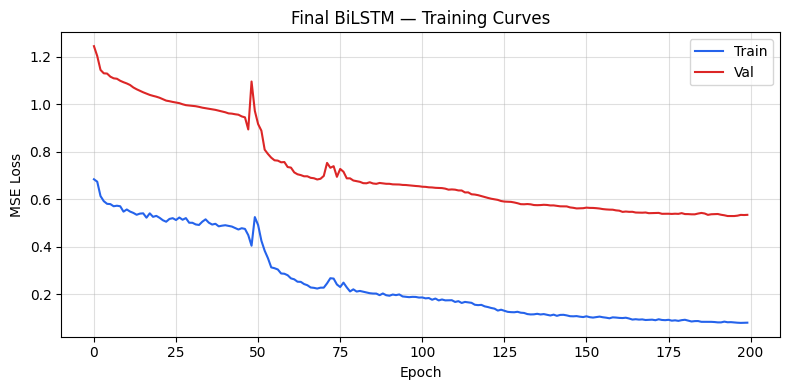

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tr_loss, label='Train', color='#2563eb')
ax.plot(vl_loss, label='Val',   color='#dc2626')
ax.set_title(f'Final {best_p["model_type"]} — Training Curves')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout(); plt.show()

In [20]:
sc_val, y_val_combined = get_clean_scores_windowed(model, val_windows_sc, val_anom_windows)
fpr_arr, tpr_arr, thrs = roc_curve(y_val_combined, sc_val)

thr_youden = youden_threshold(y_val_combined, sc_val)
thr_10fpr  = find_threshold_at_fpr(fpr_arr, tpr_arr, thrs, target_fpr=0.10)
thr_5fpr   = find_threshold_at_fpr(fpr_arr, tpr_arr, thrs, target_fpr=0.05)
thr_blind  = float(np.percentile(
    get_clean_scores_windowed(model, val_windows_sc, val_windows_sc)[0][:len(val_windows_sc)], 99
))

print(f"Youden threshold     : {thr_youden:.4f}")
print(f"FPR<=10% threshold   : {thr_10fpr:.4f}")
print(f"FPR<=5%  threshold   : {thr_5fpr:.4f}")
print(f"99th pct (blind)     : {thr_blind:.4f}")

Youden threshold     : 0.2326
FPR<=10% threshold   : 0.7132
FPR<=5%  threshold   : 1.3299
99th pct (blind)     : 2.7751


In [21]:
sc_test, y_test_combined = get_clean_scores_windowed(model, test_windows_sc, test_anom_windows)
results_by_thr = {}

for label, thr in [("Youden", thr_youden), ("FPR<=10%", thr_10fpr),
                   ("FPR<=5%", thr_5fpr),  ("Blind-99pct", thr_blind)]:
    r = evaluate(f"Best {best_p['model_type']} ({label})", y_test_combined, sc_test, thr)
    results_by_thr[label] = r
    print(f"\n--- {label} (thr={thr:.4f}) ---")
    for k in ['Recall', 'Precision', 'F1', 'FPR', 'AUC']:
        print(f"  {k:10}: {r[k]*100:.2f}%")

pr_auc = average_precision_score(y_test_combined, sc_test)
print(f"\n  PR-AUC: {pr_auc*100:.2f}%")

sc_best_test = sc_test
thr_best     = thr_10fpr
all_results[f"Best {best_p['model_type']}"] = results_by_thr["FPR<=10%"]


--- Youden (thr=0.2326) ---
  Recall    : 98.90%
  Precision : 98.21%
  F1        : 98.55%
  FPR       : 12.70%
  AUC       : 97.71%

--- FPR<=10% (thr=0.7132) ---
  Recall    : 87.17%
  Precision : 98.88%
  F1        : 92.65%
  FPR       : 6.97%
  AUC       : 97.71%

--- FPR<=5% (thr=1.3299) ---
  Recall    : 80.78%
  Precision : 99.29%
  F1        : 89.08%
  FPR       : 4.10%
  AUC       : 97.71%

--- Blind-99pct (thr=2.7751) ---
  Recall    : 76.07%
  Precision : 99.62%
  F1        : 86.27%
  FPR       : 2.05%
  AUC       : 97.71%

  PR-AUC: 99.56%


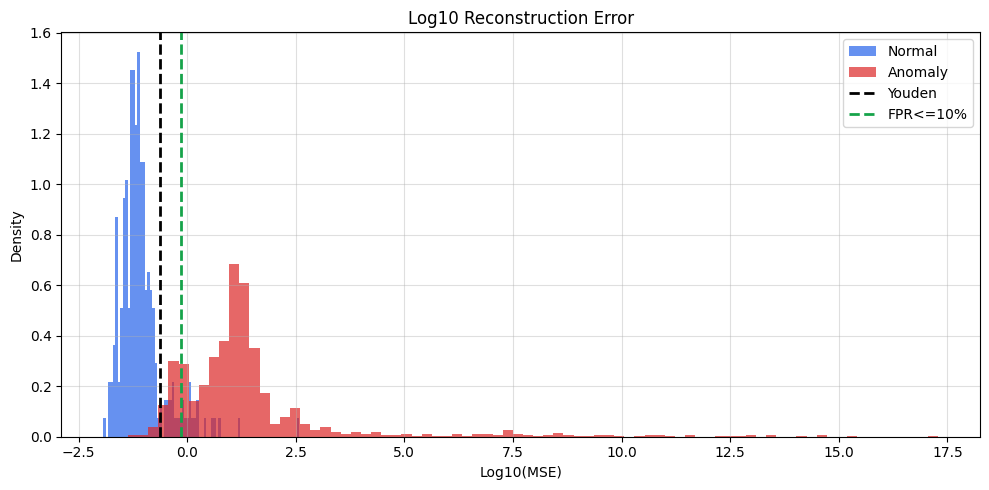

Normal  — mean=1.8295  std=24.3004  max=380.2300
Anomaly — mean=115252121497422.0469  std=4700541741891136.0000  max=195102809709087776.0000
Anomaly/Normal mean ratio: 62998087737659.7x


In [22]:
log_sc = np.log10(sc_test + 1e-9)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(log_sc[y_test_combined==0], bins=80, alpha=0.7, label='Normal',  color='#2563eb', density=True)
ax.hist(log_sc[y_test_combined==1], bins=80, alpha=0.7, label='Anomaly', color='#dc2626', density=True)
ax.axvline(np.log10(thr_youden + 1e-9), color='black',   ls='--', lw=2, label='Youden')
ax.axvline(np.log10(thr_10fpr  + 1e-9), color='#16a34a', ls='--', lw=2, label='FPR<=10%')
ax.set_title('Log10 Reconstruction Error'); ax.set_xlabel('Log10(MSE)'); ax.set_ylabel('Density')
ax.legend(fontsize=10); ax.grid(alpha=0.4)
plt.tight_layout(); plt.show()

print(f"Normal  — mean={sc_test[y_test_combined==0].mean():.4f}  std={sc_test[y_test_combined==0].std():.4f}  max={sc_test[y_test_combined==0].max():.4f}")
print(f"Anomaly — mean={sc_test[y_test_combined==1].mean():.4f}  std={sc_test[y_test_combined==1].std():.4f}  max={sc_test[y_test_combined==1].max():.4f}")
print(f"Anomaly/Normal mean ratio: {sc_test[y_test_combined==1].mean() / sc_test[y_test_combined==0].mean():.1f}x")

In [23]:
df_anom      = df_sorted[df_sorted['label'] != 'NORMAL'].reset_index(drop=True)
n_anom_w     = len(anom_windows_sc)
test_anom_df = df_anom.iloc[(n_anom_w // 2) * window_size:].iloc[:len(test_anom_windows) * window_size].copy()
test_anom_df['window_idx'] = np.repeat(np.arange(len(test_anom_windows)), window_size)[:len(test_anom_df)]

sc_anom_only   = sc_best_test[y_test_combined == 1]
pred_anom_only = (sc_anom_only >= thr_best).astype(int)
test_anom_df['predicted_anomaly'] = test_anom_df['window_idx'].map(pd.Series(pred_anom_only))

print("Detection rate per anomaly type:")
print(
    test_anom_df.groupby('label')['predicted_anomaly']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'detection_rate', 'count': 'n_windows'})
    .sort_values('detection_rate')
    .round(3)
)

Detection rate per anomaly type:
                    detection_rate  n_windows
label                                        
CALL_DROP                    0.822       8659
CAPACITY_EXHAUSTED           0.863       5216
POOR_VOICE_QUALITY           0.866      10745
HIGH_LATENCY                 0.880      12455
LOW_THROUGHPUT               0.902      14585


In [ ]:
import joblib

inference_artifacts = {
    'features': FEATURES,
    'window_size': window_size,
    'clip_bounds': clip_bounds,
    'scaler': scaler,
    'thresholds': {
        'youden': thr_youden,
        'fpr_10': thr_10fpr,
        'fpr_5': thr_5fpr,
        'blind': thr_blind,
        'best': thr_best
    },
    'model_type': best_p['model_type'],
    'model_params': best_p,
    'train_config': final_config
}

ARTIFACTS_PATH = os.path.join(OUT_DIR, 'inference_artifacts.joblib')
MODEL_PATH = os.path.join(OUT_DIR, 'best_ae_model.pth')

joblib.dump(inference_artifacts, ARTIFACTS_PATH)
torch.save(model.state_dict(), MODEL_PATH)

print(f"✅ Preprocessing artifacts saved to: {ARTIFACTS_PATH}")
print(f"✅ Model weights saved to: {MODEL_PATH}")


✅ Preprocessing artifacts saved to: outputs/inference_artifacts.joblib
✅ Model weights saved to: outputs/best_ae_model.pth
